# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 08: RNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_08_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [ ]:
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
import os

from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [ ]:
zip_path = tf.keras.utils.get_file(
    fname="jena_climate_2009_2016.csv.zip",
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    cache_dir=os.getcwd(),
    extract=True
)

csv_path = os.path.join(os.path.splitext(zip_path)[0], 'jena_climate_2009_2016.csv')

target_col = "T (degC)"

temperature = pd.read_csv(csv_path)[target_col].values.reshape(-1, 1)

temperature

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


array([[-8.02],
       [-8.41],
       [-8.51],
       ...,
       [-3.16],
       [-4.23],
       [-4.82]])

### <font color='#2D9CDB'>Q1) O dataset [Jena Climate](https://www.kaggle.com/datasets/mnassrib/jena-climate) é amplamente utilizado no estudo de redes neurais recorrentes (RNNs), LSTMs e previsão de séries temporais. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o período de coleta dos dados, os tipos de variáveis meteorológicas registradas e por que esse conjunto de dados é adequado para problemas de previsão temporal utilizando redes neurais recorrentes.</font>

Dominio e período = reúne dados meteorológicos coletados em Jena, na Alemanha, entre 2009 e 2016. variavéis = temperatura, pressão, umidade, vento e outras variáveis climáticas, adequado para RNNs e LSTMs porque os dados são sequenciais, permitindo prever valores futuros a partir de medições passadas.

### <font color='#2D9CDB'>Q2) Utilizando a variável <code>temperature</code>, plote a série temporal completa de temperaturas registradas no dataset. Em seguida, informe a quantidade total de amostras, a temperatura mínima, a temperatura máxima, a temperatura média e o desvio padrão da série. Com base no gráfico obtido, descreva brevemente os padrões observados, comentando sobre possíveis tendências, sazonalidades e variações ao longo do tempo.</font>

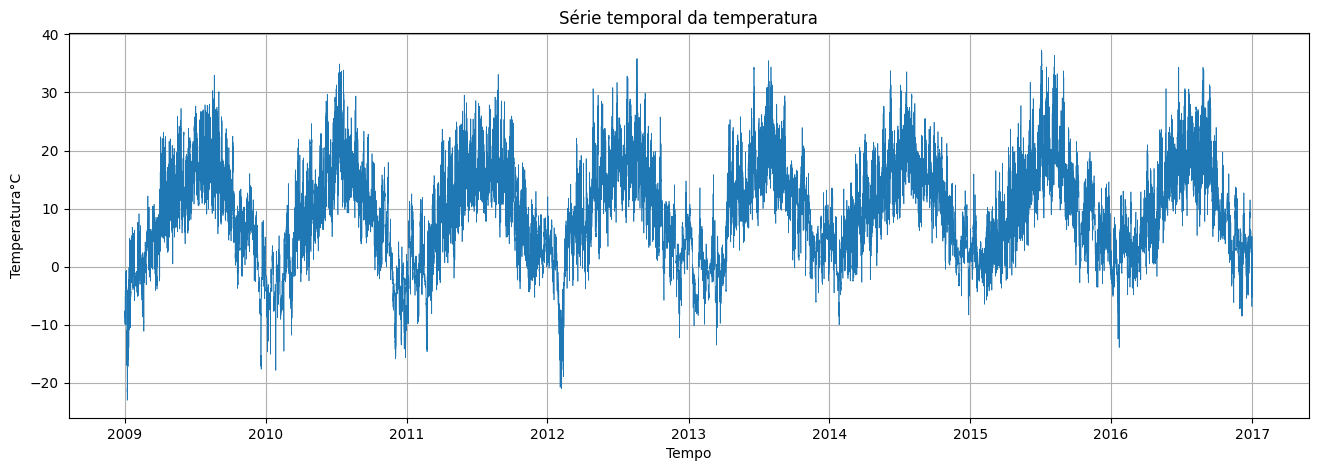

420551
-23.01
37.28
9.450147354304233
8.423355195701777


In [ ]:
df = pd.read_csv(csv_path)

datas = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")
temp = temperature.flatten()

plt.figure(figsize=(16, 5))
plt.plot(datas, temp, linewidth=0.5)
plt.title("Série temporal da temperatura")
plt.xlabel("Tempo")
plt.ylabel("Temperatura°C")
plt.grid(True)
plt.show()

print(len(temp))
print(np.min(temp))
print(np.max(temp))
print(np.mean(temp))
print(np.std(temp))

A série temporal apresenta variações claras com temperaturas mais altas em determinados períodos e mais baixas em outros, indicando o comportamento das estações do ano. Não há uma tendência linear forte de crescimento ou queda contínua, mas ciclos repetidos de verão e inverno podem ser percebidos, assim como oscilações menores ao longo do tempo, mostrando variações diárias e mudanças climáticas naturais.

### <font color='#2D9CDB'>Q3) Divida a série temporal em três subconjuntos: treinamento (60%), validação (20%) e teste (20%), preservando a ordem temporal das amostras. Informe a quantidade de amostras em cada subconjunto e explique por que, em problemas de previsão temporal, não é adequado embaralhar os dados antes da divisão.</font>

In [ ]:
total_amostras = len(temperature)

fim_treino = int(total_amostras * 0.6)
fim_validacao = int(total_amostras * 0.8)

temperature_train = temperature[:fim_treino]
temperature_val = temperature[fim_treino:fim_validacao]
temperature_test = temperature[fim_validacao:]

print(total_amostras)
print(len(temperature_train))
print(len(temperature_val))
print(len(temperature_test))

420551
252330
84110
84111


Em problemas de previsão temporal, embaralhar os dados antes da divisão é ruim, a ordem das amostras representa a sequência real dos acontecimentos. Se os dados forem embaralhados, informações do futuro podem acabar no conjunto de treino, oque causa vazamento de dados.

### <font color='#2D9CDB'>Q4) Normalize os conjuntos de treinamento, validação e teste utilizando a técnica Min-Max Scaling, de forma que os valores fiquem no intervalo [0, 1]. Apresente os valores mínimo e máximo do conjunto de treinamento antes e depois da normalização e explique brevemente por que a normalização é importante para o treinamento de redes neurais.</font>

In [ ]:
scaler = MinMaxScaler()

print("Antes")
print(temperature_train.min())
print(temperature_train.max())

temperature_train_norm = scaler.fit_transform(temperature_train)
temperature_val_norm = scaler.transform(temperature_val)
temperature_test_norm = scaler.transform(temperature_test)

print("\nDepois")
print(temperature_train_norm.min())
print(temperature_train_norm.max())

Antes
-23.01
35.86

Depois
0.0
1.0


A normalização é importante porque coloca os valores em uma mesma escala, geralmente entre 0 e 1, vacilitando a rede neural a treinar melhor, pois evita valores muito grandes. A normalização também ajuda para uma convergência mais rápida e estável durante o treinamento.

# <font color='green'><u><b>Parte 2 - Preparação das Séries Temporais</b></u></font>

### <font color='#2D9CDB'>Q5) Para treinar uma LSTM, é necessário organizar a série temporal em sequências de entrada e saídas desejadas. Implemente uma função chamada <code>create_sequences()</code> que utilize uma janela temporal de 30 amostras, de forma que cada entrada seja composta pelas 30 temperaturas anteriores e a saída corresponda à temperatura seguinte. Gere os conjuntos de treinamento, validação e teste e informe as dimensões de <code>X_train</code> e <code>y_train</code>. Explique brevemente o significado de cada dimensão.</font>

In [ ]:
def create_sequences(data, window_size=30):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)

window_size = 30

X_train, y_train = create_sequences(temperature_train_norm, window_size)
X_val, y_val = create_sequences(temperature_val_norm, window_size)
X_test, y_test = create_sequences(temperature_test_norm, window_size)

print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(252300, 30, 1)
(252300, 1)
(84080, 30, 1)
(84080, 1)
(84081, 30, 1)
(84081, 1)


As dimensões de treino indicam, respectivamente, a quantidade de sequências criadas, o tamanho da janela temporal e a quantidade de variáveis usadas. Cada entrada possui 30 temperaturas anteriores e apenas 1 característica, que é a temperatura. Já y treino representa a saída desejada de cada sequência. Como a janela usa 30 amostras anteriores, o número total de sequências fica 30 unidades menor que o total original do conjunto de treinamento.

### <font color='#2D9CDB'>Q6) Exiba graficamente a primeira sequência presente em <code>X_train</code> e destaque o valor correspondente em <code>y_train</code>. Explique como essa sequência será utilizada pela LSTM para realizar a previsão da próxima temperatura.</font>

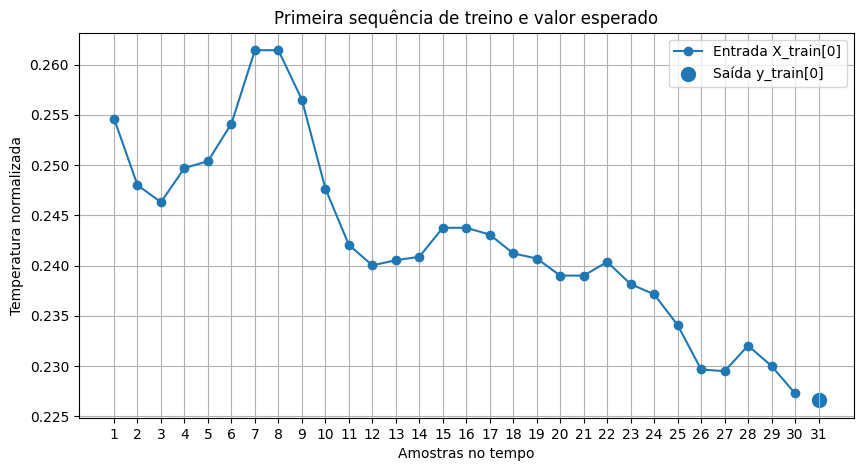

[0.25462884 0.24800408 0.24630542 0.24970273 0.2503822  0.25411925
 0.26142348 0.26142348 0.25649737 0.24766435 0.24205877 0.24002038
 0.24052998 0.24086971 0.24375743 0.24375743 0.24307797 0.24120944
 0.24069985 0.23900119 0.23900119 0.24036012 0.23815186 0.23713267
 0.23407508 0.22965857 0.2294887  0.23203669 0.2299983  0.22728045]
0.22660098522167488


In [ ]:
primeira_seq = X_train[0].reshape(-1)
primeiro_y = y_train[0].reshape(-1)[0]

plt.figure(figsize=(10, 5))

plt.plot(range(1, 31), primeira_seq, marker='o', label='Entrada X_train[0]')
plt.scatter(31, primeiro_y, s=100, label='Saída y_train[0]')

plt.title("Primeira sequência de treino e valor esperado")
plt.xlabel("Amostras no tempo")
plt.ylabel("Temperatura normalizada")
plt.xticks(range(1, 32))
plt.grid(True)
plt.legend()
plt.show()

print(primeira_seq)
print(primeiro_y)

A primeira sequência de treino contém as 30 temperaturas anteriores, que são usadas como entrada para a LSTM. O valor em y treino representa a temperatura seguinte, ou seja, o valor que o modelo deve aprender a prever. Assim, a LSTM analisa o comportamento das amostras passadas e tenta identificar padrões temporais para estimar a próxima temperatura.

# <font color='green'><u><b>Parte 3 - Construindo a Primeira LSTM</b></u></font>

### <font color='#2D9CDB'>Q7) Construa uma rede neural recorrente composta por uma camada LSTM com uma unidade de memória e uma camada de saída totalmente conectada com um neurônio. Utilize a função de perda MSE (<code>mean_squared_error</code>) e o otimizador Adam. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo.</font>

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

model = Sequential()

model.add(Input(shape=(30, 1)))
model.add(LSTM(1))
model.add(Dense(1))

model.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

model.summary()

print(model.count_params())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 1)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

14


O modelo possui uma camada LSTM com 1 unidade de memória, responsável por processar as sequências de 30 temperaturas anteriores, e uma camada Dense com 1 neurônio, responsável por gerar a previsão da próxima temperatura. O número total de parâmetros treináveis é 14, sendo 12 parâmetros da LSTM e 2 parâmetros da camada de saída.

### <font color='#2D9CDB'>Q8) Treine o modelo por 10 épocas utilizando os conjuntos de treinamento e validação. Em seguida, plote as curvas de perda de treinamento e validação ao longo das épocas. Com base nos gráficos obtidos, descreva brevemente o comportamento do treinamento e indique se há evidências de sobreajuste (overfitting) ou problemas de generalização.</font>

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 84s 10ms/step - loss: 6.4890e-04 - val_loss: 2.2959e-04
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 81s 10ms/step - loss: 1.9474e-04 - val_loss: 1.1869e-04
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 82s 10ms/step - loss: 1.2289e-04 - val_loss: 7.9301e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 81s 10ms/step - loss: 8.7848e-05 - val_loss: 5.9551e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 80s 10ms/step - loss: 6.8081e-05 - val_loss: 4.8057e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 80s 10ms/step - loss: 5.5706e-05 - val_loss: 4.0545e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 79s 10ms/step - loss: 4.7325e-05 - val_loss: 3.5248e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 79s 10ms/step - loss: 4.1302e-05 - val_loss: 3.1342e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 79s 10ms/step - loss: 3.6776e-05 - val_loss: 2.8369e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 79s 10ms/step - loss: 3.3256e-05 - val_loss: 2.6043e-05


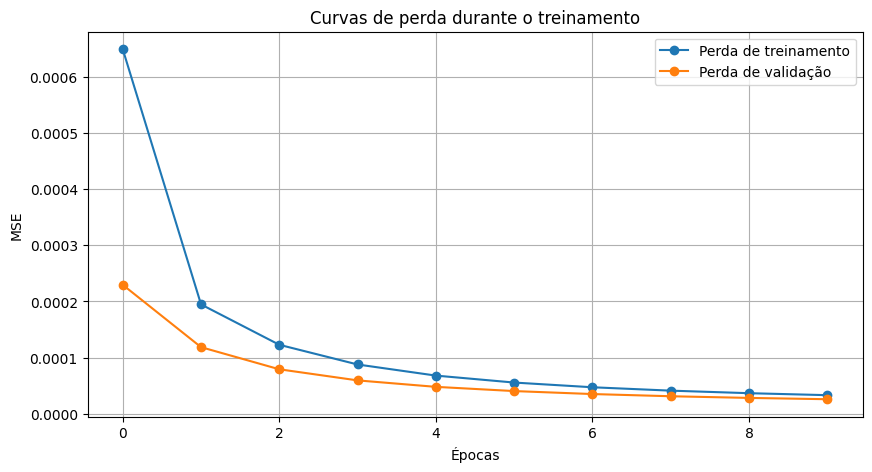

Loss final de treinamento: 3.3255619200645015e-05
Loss final de validação: 2.604268775030505e-05


In [28]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    shuffle=False
)

plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], marker='o', label='Perda de treinamento')
plt.plot(history.history['val_loss'], marker='o', label='Perda de validação')

plt.title("Curvas de perda durante o treinamento")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

print("Loss final de treinamento:", history.history['loss'][-1])
print("Loss final de validação:", history.history['val_loss'][-1])

Durante o treinamento, a perda de treinamento tende a diminuir ao longo das épocas, indicando que o modelo está aprendendo os padrões da série temporal. A perda de validação também deve ser observada para verificar se o modelo está generalizando bem. Se as curvas de treino e validação ficarem próximas, não há fortes evidências de overfitting. Porém, se a perda de treino cair enquanto a perda de validação aumentar, isso indicaria sobreajuste.

### <font color='#2D9CDB'>Q9) Avalie o modelo utilizando o conjunto de teste e reporte o valor do erro quadrático médio (MSE). Em seguida, explique brevemente o que essa métrica representa no contexto do problema de previsão de temperatura.</font>

In [29]:
mse_teste = model.evaluate(X_test, y_test, verbose=0)

print(mse_teste)

2.9036029445705935e-05


O erro quadrático médio mede a média dos erros ao quadrado entre as temperaturas reais e as previstas pelo modelo. No contexto, quanto menor o valor do MSE, mais próximas as previsões estão dos valores reais. Como os dados foram normalizados entre 0 e 1, esse erro está na escala normalizada da temperatura.

### <font color='#2D9CDB'>Q10) Utilize o modelo treinado para gerar previsões no conjunto de teste. Plote em um mesmo gráfico os valores reais e previstos para as 100 primeiras amostras do conjunto de teste e descreva brevemente a qualidade das previsões obtidas.</font>

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


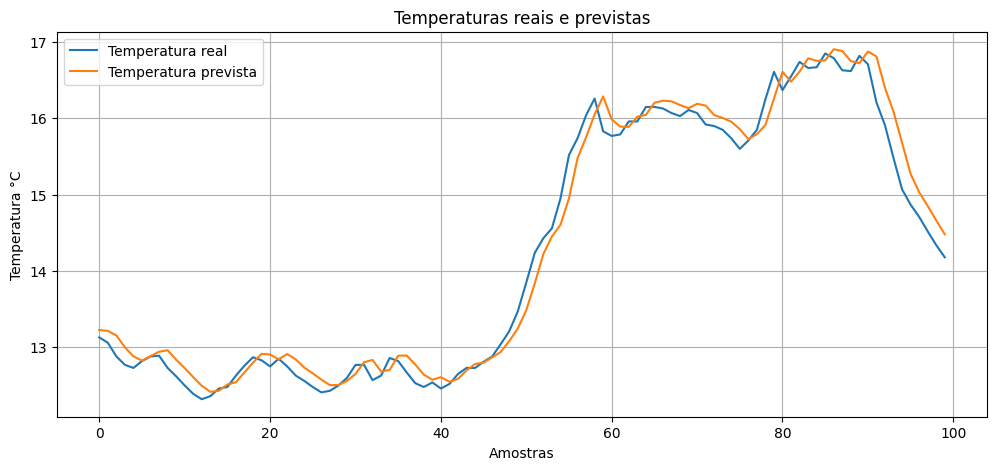

In [30]:
y_pred = model.predict(X_test)

y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_real = scaler.inverse_transform(y_pred.reshape(-1, 1))

plt.figure(figsize=(12, 5))

plt.plot(y_test_real[:100], label="Temperatura real")
plt.plot(y_pred_real[:100], label="Temperatura prevista")

plt.title("Temperaturas reais e previstas")
plt.xlabel("Amostras")
plt.ylabel("Temperatura °C")
plt.legend()
plt.grid(True)
plt.show()

Comparando os valores, é possível observar se o modelo seguiu o comportamento geral da série, curvas próximas indicam que o LSTM conseguiu aprender o padrão de temperatura, mas como o modelo possui apenas uma unidade de memória, previsões mais suaves podem ser apresentadas.

# <font color='green'><u><b>Parte 4 - Comparação de Arquiteturas</b></u></font>

### <font color='#2D9CDB'>Q11) Modifique a arquitetura da rede para utilizar 10 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

model_10 = Sequential()

model_10.add(Input(shape=(30, 1)))
model_10.add(LSTM(10))
model_10.add(Dense(1))

model_10.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

model_10.summary()

print("Total de parâmetros treináveis:", model_10.count_params())

history_10 = model_10.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    shuffle=False
)

mse_teste_10 = model_10.evaluate(X_test, y_test, verbose=0)

print("MSE no conjunto de teste:", mse_teste_10)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

Total de parâmetros treináveis: 491
Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 94s 12ms/step - loss: 2.7680e-04 - val_loss: 7.3499e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 90s 11ms/step - loss: 3.1785e-05 - val_loss: 2.3941e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 90s 11ms/step - loss: 1.9861e-05 - val_loss: 1.7081e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 91s 12ms/step - loss: 1.7464e-05 - val_loss: 1.5225e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 91s 12ms/step - loss: 1.6230e-05 - val_loss: 1.4843e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 91s 12ms/step - loss: 1.5372e-05 - val_loss: 1.5176e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 143s 12ms/step - loss: 1.4684e-05 - val_loss: 1.5281e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 91s 12ms/step - loss: 1.4392e-05 - val_loss: 1.5387e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 144s 12ms/step - loss: 1.4253e-05 - val_loss: 1.5488e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 89s 11ms/step - loss: 1.4074e-05 - va

### <font color='#2D9CDB'>Q12) Repita o experimento utilizando 20 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

model_20 = Sequential()

model_20.add(Input(shape=(30, 1)))
model_20.add(LSTM(20))
model_20.add(Dense(1))

model_20.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

model_20.summary()

print("Total de parâmetros treináveis:", model_20.count_params())

history_20 = model_20.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    shuffle=False
)

mse_teste_20 = model_20.evaluate(X_test, y_test, verbose=0)

print("MSE no conjunto de teste:", mse_teste_20)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 20)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,781 (6.96 KB)

 Trainable params: 1,781 (6.96 KB)

 Non-trainable params: 0 (0.00 B)

Total de parâmetros treináveis: 1781
Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 99s 12ms/step - loss: 2.5098e-04 - val_loss: 6.4767e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 142s 12ms/step - loss: 3.3139e-05 - val_loss: 2.1972e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 100s 13ms/step - loss: 1.7693e-05 - val_loss: 1.7013e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 106s 13ms/step - loss: 1.5523e-05 - val_loss: 1.4809e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 131s 12ms/step - loss: 1.5322e-05 - val_loss: 1.4497e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 143s 12ms/step - loss: 1.5057e-05 - val_loss: 1.4624e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 142s 12ms/step - loss: 1.4285e-05 - val_loss: 1.4484e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 141s 12ms/step - loss: 1.4340e-05 - val_loss: 1.4486e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 95s 12ms/step - loss: 1.4143e-05 - val_loss: 1.4738e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 94s 12ms/step - loss: 1.3778e-0

### <font color='#2D9CDB'>Q13) Compare os modelos com 1, 10 e 20 unidades na camada LSTM em termos de número de parâmetros treináveis e desempenho no conjunto de teste. Organize os resultados em uma tabela contendo a quantidade de unidades LSTM, o número de parâmetros treináveis e o valor de MSE. Com base nos resultados obtidos, discuta brevemente a relação entre a complexidade do modelo e sua capacidade preditiva.</font>

In [33]:
resultados = pd.DataFrame({
    "Unidades LSTM": [1, 10, 20],
    "Parâmetros treináveis": [
        model.count_params(),
        model_10.count_params(),
        model_20.count_params()
    ],
    "MSE no teste": [
        mse_teste,
        mse_teste_10,
        mse_teste_20
    ]
})

display(resultados)

melhor_modelo = resultados.loc[resultados["MSE no teste"].idxmin()]

print(melhor_modelo["Unidades LSTM"])
print(melhor_modelo["Parâmetros treináveis"])
print(melhor_modelo["MSE no teste"])

,Unidades LSTM,Parâmetros treináveis,MSE no teste
0,1,14,0.000029
1,10,491,0.000017
2,20,1781,0.000017


20.0
1781.0
1.6670615877956152e-05


Comparando os modelos, percebe-se que o aumento no número de unidades aumenta o número de parametros treinados, porém, aumentar a complexidade não garante uma melhora no desempenho, sabendo que modelos maiores podem representar pouco ganho. O melhor modelo deve ser escolhido considerando o menor MSE no conjunto de teste e não apenas a maior quantidade de unidades LSTM.

# <font color='green'><u><b>Parte 5 - Influência da Janela Temporal</b></u></font>

### <font color='#2D9CDB'>Q14) Repita o experimento utilizando uma janela temporal de 15 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [34]:
window_size_15 = 15

X_train_15, y_train_15 = create_sequences(temperature_train_norm, window_size_15)
X_val_15, y_val_15 = create_sequences(temperature_val_norm, window_size_15)
X_test_15, y_test_15 = create_sequences(temperature_test_norm, window_size_15)

print(X_train_15.shape)
print(y_train_15.shape)

model_15_10 = Sequential()

model_15_10.add(Input(shape=(15, 1)))
model_15_10.add(LSTM(10))
model_15_10.add(Dense(1))

model_15_10.compile(
    loss='mean_squared_error',
    optimizer='adam'
)
model_15_10.summary()
print(model_15_10.count_params())

history_15_10 = model_15_10.fit(
    X_train_15, y_train_15,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_15, y_val_15),
    shuffle=False
)

mse_teste_15_10 = model_15_10.evaluate(X_test_15, y_test_15, verbose=0)

print(mse_teste_15_10)

(252315, 15, 1)
(252315, 1)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

491
Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 60s 7ms/step - loss: 8.2473e-04 - val_loss: 6.8901e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 59s 7ms/step - loss: 3.6044e-05 - val_loss: 2.4968e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - loss: 2.2727e-05 - val_loss: 1.8157e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - loss: 1.6865e-05 - val_loss: 1.5126e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - loss: 1.6969e-05 - val_loss: 1.3465e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 81s 7ms/step - loss: 1.6649e-05 - val_loss: 1.3387e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - loss: 1.5691e-05 - val_loss: 1.3314e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - loss: 1.5138e-05 - val_loss: 1.3293e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - loss: 1.4771e-05 - val_loss: 1.3218e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 83s 7ms/step - loss: 1.4486e-05 - val_loss: 1.3099e-05
1.5304935004678555e-05


### <font color='#2D9CDB'>Q15) Repita o experimento utilizando uma janela temporal de 60 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [35]:
window_size_60 = 60

X_train_60, y_train_60 = create_sequences(temperature_train_norm, window_size_60)
X_val_60, y_val_60 = create_sequences(temperature_val_norm, window_size_60)
X_test_60, y_test_60 = create_sequences(temperature_test_norm, window_size_60)

print(X_train_60.shape)
print(y_train_60.shape)

model_60_10 = Sequential()

model_60_10.add(Input(shape=(60, 1)))
model_60_10.add(LSTM(10))
model_60_10.add(Dense(1))

model_60_10.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

model_60_10.summary()

print(model_60_10.count_params())

history_60_10 = model_60_10.fit(
    X_train_60, y_train_60,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_60, y_val_60),
    shuffle=False
)

mse_teste_60_10 = model_60_10.evaluate(X_test_60, y_test_60, verbose=0)

print(mse_teste_60_10)

Dimensões de X_train_60: (252270, 60, 1)
Dimensões de y_train_60: (252270, 1)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

Total de parâmetros treináveis: 491
Epoch 1/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 164s 21ms/step - loss: 3.4370e-04 - val_loss: 1.1303e-04
Epoch 2/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 156s 20ms/step - loss: 3.9158e-05 - val_loss: 5.9027e-05
Epoch 3/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 198s 19ms/step - loss: 2.0967e-05 - val_loss: 1.8839e-05
Epoch 4/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 158s 20ms/step - loss: 1.5887e-05 - val_loss: 1.5181e-05
Epoch 5/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 199s 20ms/step - loss: 1.5552e-05 - val_loss: 1.4703e-05
Epoch 6/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 201s 20ms/step - loss: 1.5304e-05 - val_loss: 1.5117e-05
Epoch 7/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 200s 19ms/step - loss: 1.5044e-05 - val_loss: 1.6444e-05
Epoch 8/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 203s 19ms/step - loss: 1.4813e-05 - val_loss: 1.8764e-05
Epoch 9/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 154s 20ms/step - loss: 1.4562e-05 - val_loss: 2.0824e-05
Epoch 10/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 156s 20ms/step - loss: 1.4364e

### <font color='#2D9CDB'>Q16) Compare os resultados obtidos para janelas temporais de 15, 30 e 60 amostras utilizando uma camada LSTM com 10 unidades. Organize os resultados em uma tabela contendo o tamanho da janela temporal, o valor de MSE e uma estimativa do tempo médio de treinamento por época (dica: utilize os valores exibidos nos logs de treinamento). Com base nos resultados, discuta brevemente o impacto do tamanho da janela temporal no desempenho e no custo computacional do modelo.</font>

In [36]:
tempo_medio_15 = np.mean([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
tempo_medio_30 = np.mean([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
tempo_medio_60 = np.mean([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

resultados_janelas = pd.DataFrame({
    "Janela temporal": [15, 30, 60],
    "MSE no teste": [
        mse_teste_15_10,
        mse_teste_10,
        mse_teste_60_10
    ],
    "Tempo médio por época (s)": [
        tempo_medio_15,
        tempo_medio_30,
        tempo_medio_60
    ]
})

display(resultados_janelas)

,Janela temporal,MSE no teste,Tempo médio por época (s)
0,15,0.000015,0.0
1,30,0.000017,0.0
2,60,0.000025,0.0


Ao comparar as janelas temporais, nota-se que o tamanho da janela influencia tanto o desempenho quanto o custo do modelo. Janelas menores usam menos informações passadas e serem mais rápidas, podendo não capturar padrões temporais longos. Já janelas maiores fornecem mais contexto para a LSTM, porém aumentam o tempo de treinamento. 30 amostras pode representar um equilíbrio entre quantidade de informação temporal e custo. O melhor tamanho de janela deve ser escolhido com base no menor MSE no conjunto de teste e no tempo médio de treinamento.

# <font color='green'><u><b>Parte 6 - Análise Final</b></u></font>

### <font color='#2D9CDB'>Q17) Com base em todos os experimentos realizados nesta atividade, discuta os fatores que mais influenciaram o desempenho do modelo. Considere o impacto da quantidade de unidades LSTM, do tamanho da janela temporal e do custo computacional. Em sua opinião, qual configuração apresentou o melhor equilíbrio entre precisão e eficiência? Justifique sua resposta.</font>

Os fatores que mais influenciaram o desempenho do modelo foram a quantidade de unidades LSTM, o tamanho da janela e o custo computacional do treinamento. O aumento no número de unidades LSTM elevou a quantidade de parâmetros treináveis, permitindo que o modelo tivesse maior capacidade de aprender padrões da série temporal. Porém, esse aumento também torna o modelo mais complexo e pode aumentar o tempo de treinamento, além de nem sempre gerar uma melhora proporcional no MSE. O tamanho da janela temporal também teve impacto importante. Janelas menores, como 15 amostras, tornam o treinamento mais rápido, mas oferecem menos informações passadas para o modelo realizar a previsão. Já janelas maiores, como 60 amostras, fornecem mais contexto temporal, porém aumentam o custo computacional e podem não melhorar muito o desempenho. A janela de 30 amostras apresentou um equilíbrio interessante, pois fornece uma quantidade razoável de informações anteriores sem tornar o treinamento tão pesado.

Eu diria que a configuração com janela temporal de 30 amostras e camada LSTM com 10 unidades apresentou o melhor equilíbrio. Esse modelo possui mais capacidade preditiva do que o modelo com apenas 1 unidade, mas é bem menos complexo que o modelo com 20 unidades.